# Pipeline 03: Advanced Color Science Extraction

**Goal:** Extract non-linear color grading: parametric tone curves (S-curves) and 8-channel HSL color mixer shifts. These capture the Fuji-like color science that simple linear params can't represent.

**Depends on:** Pipeline 02 (SAM masks, cache), `shared.py`

**Output:** `simon_advanced_color_profile.json`

**Runtime:** GPU required (SAM + kornia tensor ops).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

PROJECT = '/content/drive/MyDrive/photo-style-rl'

!pip install segment-anything opencv-python-headless kornia tqdm -q

import shutil
shutil.copy(f'{PROJECT}/src/shared.py', '/content/shared.py')

import os, json, cv2, torch
import numpy as np
import kornia
from PIL import Image
from tqdm.notebook import tqdm
from collections import defaultdict
from segment_anything import sam_model_registry, SamAutomaticMaskGenerator

from shared import (
    PROJECT, RAW_DIR, EDITED_DIR, CHECKPOINTS_DIR, HUE_BINS, TONE_BAND_CENTERS,
    pair_files, get_mask_properties, classify_mask_heuristic,
    save_style_profile
)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

# Load mask cache from Pipeline 02
CACHE_PATH = f'{CHECKPOINTS_DIR}/mask_labels_cache.json'
mask_cache = {}
if os.path.exists(CACHE_PATH):
    with open(CACHE_PATH, 'r') as f:
        mask_cache = json.load(f)
    print(f"Loaded mask cache: {len(mask_cache)} images")

# Load SAM
SAM_CHECKPOINT = f'{CHECKPOINTS_DIR}/sam_vit_h_4b8939.pth'
sam = sam_model_registry['vit_h'](checkpoint=SAM_CHECKPOINT).to(device)
auto_generator = SamAutomaticMaskGenerator(
    sam, points_per_side=32, pred_iou_thresh=0.86,
    stability_score_thresh=0.92, min_mask_region_area=0,
)
pairs = pair_files()
print(f"Ready: {len(pairs)} pairs")

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 76.6 MB/s eta 0:00:00
Device: cuda
Loaded mask cache: 287 images
Ready: 287 pairs


In [2]:
class AdvancedColorExtractor:
    """GPU-accelerated tone curve and HSL mixer extraction using kornia."""
    def __init__(self, device, min_pixels=1000):
        self.device = device
        self.min_pixels = min_pixels

    def extract_tone_curve(self, raw_lum, edt_lum):
        """Compute luminance shifts across 5 tonal bands."""
        curve = {}
        ranges = {
            'blacks': (0.0, 0.1), 'shadows': (0.1, 0.35), 'midtones': (0.35, 0.65),
            'highlights': (0.65, 0.9), 'whites': (0.9, 1.0),
        }
        for name, (lo, hi) in ranges.items():
            mask = (raw_lum >= lo) & (raw_lum < hi)
            if mask.sum() > 50:
                curve[name] = round((torch.median(edt_lum[mask]) - torch.median(raw_lum[mask])).item() * 100, 2)
            else:
                curve[name] = 0.0
        return curve

    def extract_hsl_mixer(self, raw_hsv, edt_hsv):
        """Compute per-color-bin H/S/L shifts with circular hue handling."""
        mixer = {}
        raw_hue_deg = raw_hsv[:, 0] * 360.0

        for color, conditions in HUE_BINS.items():
            mask = torch.zeros_like(raw_hue_deg, dtype=torch.bool)
            for (lo, hi) in conditions:
                mask |= (raw_hue_deg >= lo) & (raw_hue_deg < hi)

            if mask.sum() < 50:
                continue

            # Circular hue diff
            h_diff = edt_hsv[mask, 0] - raw_hsv[mask, 0]
            h_diff = (h_diff + 0.5) % 1.0 - 0.5
            mixer[color] = {
                'h': round((torch.median(h_diff) * 360.0).item(), 1),
                's': round((torch.median(edt_hsv[mask, 1] - raw_hsv[mask, 1]) * 100).item(), 1),
                'l': round((torch.median(edt_hsv[mask, 2] - raw_hsv[mask, 2]) * 100).item(), 1),
            }
        return mixer

    @torch.no_grad()
    def process_pair(self, raw_np, edt_np, regions):
        """Extract tone curve + HSL mixer per labeled region."""
        raw_t = kornia.image_to_tensor(raw_np, keepdim=False).to(self.device).float() / 255.0
        edt_t = kornia.image_to_tensor(edt_np, keepdim=False).to(self.device).float() / 255.0

        raw_hsv = kornia.color.rgb_to_hsv(raw_t).squeeze(0).permute(1, 2, 0)
        edt_hsv = kornia.color.rgb_to_hsv(edt_t).squeeze(0).permute(1, 2, 0)

        raw_lum = 0.299*raw_t.squeeze(0)[0] + 0.587*raw_t.squeeze(0)[1] + 0.114*raw_t.squeeze(0)[2]
        edt_lum = 0.299*edt_t.squeeze(0)[0] + 0.587*edt_t.squeeze(0)[1] + 0.114*edt_t.squeeze(0)[2]

        profiles = {}
        for label, mask_np in regions.items():
            mask_t = torch.from_numpy(mask_np).to(self.device).bool()
            if mask_t.sum() < self.min_pixels:
                continue
            profiles[label] = {
                'tone_curve': self.extract_tone_curve(raw_lum[mask_t], edt_lum[mask_t]),
                'color_mixer': self.extract_hsl_mixer(raw_hsv[mask_t], edt_hsv[mask_t]),
            }
        return profiles


# Extraction loop
extractor = AdvancedColorExtractor(device=device)
master_stats = defaultdict(lambda: {
    'tone_curve': defaultdict(list),
    'color_mixer': defaultdict(lambda: defaultdict(list)),
})

print(f"Extracting advanced color science from {len(pairs)} pairs...")
for raw_f, edt_f in tqdm(pairs, desc="Color Extraction"):
    try:
        raw_img = np.array(Image.open(os.path.join(RAW_DIR, raw_f)).convert("RGB"))
        edt_img = np.array(Image.open(os.path.join(EDITED_DIR, edt_f)).convert("RGB"))

        scale = 1024 / max(raw_img.shape[:2])
        new_size = (int(raw_img.shape[1]*scale), int(raw_img.shape[0]*scale))
        raw_eval = cv2.resize(raw_img, new_size)
        edt_eval = cv2.resize(edt_img, new_size)

        # Segment + label (heuristic + cache, no live Claude calls needed)
        raw_masks = auto_generator.generate(raw_eval)
        raw_masks = sorted(raw_masks, key=lambda x: x['area'], reverse=True)[:8]

        labeled_regions = {}
        for idx, md in enumerate(raw_masks):
            props = get_mask_properties(md['segmentation'], raw_eval)
            h_label, h_conf = classify_mask_heuristic(props)
            label = h_label if h_conf >= 0.6 else mask_cache.get(raw_f, {}).get(str(idx), 'unknown')
            if label != 'unknown':
                labeled_regions[label] = md['segmentation']

        pair_profiles = extractor.process_pair(raw_eval, edt_eval, labeled_regions)
        for label, data in pair_profiles.items():
            for k, v in data['tone_curve'].items():
                master_stats[label]['tone_curve'][k].append(v)
            for color, shifts in data['color_mixer'].items():
                for k, v in shifts.items():
                    master_stats[label]['color_mixer'][color][k].append(v)

    except Exception as e:
        print(f"\nError on {raw_f}: {e}")

# Aggregate with medians
final_profile = {}
for label, data in master_stats.items():
    sample_size = len(list(data['tone_curve'].values())[0]) if data['tone_curve'] else 0
    if sample_size < len(pairs) * 0.05:
        continue

    final_profile[label] = {'tone_curve': {}, 'color_mixer': {}}
    for band, vals in data['tone_curve'].items():
        if vals:
            final_profile[label]['tone_curve'][band] = round(float(np.median(vals)), 2)
    for color, shifts in data['color_mixer'].items():
        final_profile[label]['color_mixer'][color] = {
            k: round(float(np.median(shifts[k])), 1) if shifts[k] else 0.0
            for k in ('h', 's', 'l')
        }

path = save_style_profile(final_profile, 'simon_advanced_color_profile.json')
print(f"\nAdvanced color profile saved: {path}")
print(f"Regions: {list(final_profile.keys())}")

Extracting advanced color science from 287 pairs...


Color Extraction:   0%|          | 0/287 [00:00<?, ?it/s]


Advanced color profile saved: /content/drive/MyDrive/photo-style-rl/checkpoints/simon_advanced_color_profile.json
Regions: ['ground', 'subject', 'background', 'highlight_area', 'clothing', 'sky', 'building', 'shadow_area', 'face', 'foliage', 'water']


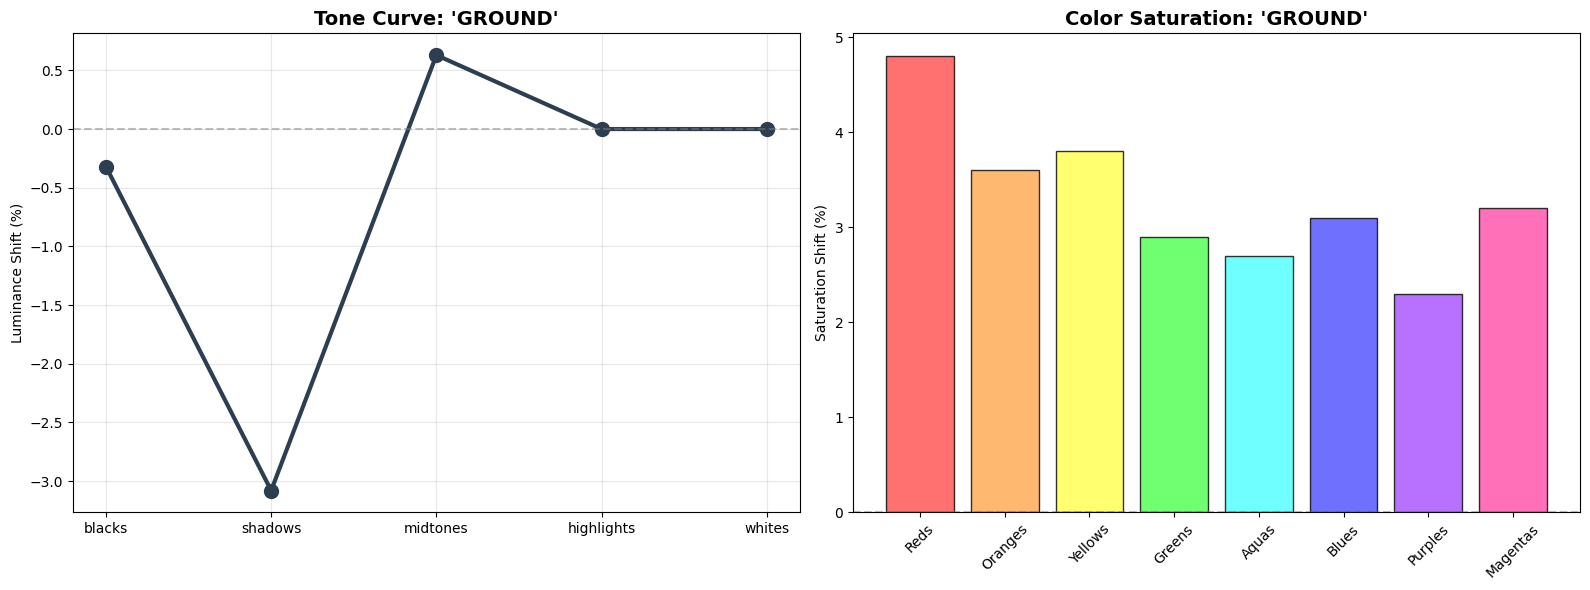

Pipeline 03 complete. Next: Pipeline 04 (Inference Demo)


In [3]:
import matplotlib.pyplot as plt

if final_profile:
    test_region = list(final_profile.keys())[0]
    data = final_profile[test_region]

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    # Tone curve
    bands = ['blacks', 'shadows', 'midtones', 'highlights', 'whites']
    shifts = [data['tone_curve'].get(b, 0) for b in bands]
    ax1.plot(bands, shifts, marker='o', color='#2c3e50', linewidth=3, markersize=10)
    ax1.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax1.set_title(f"Tone Curve: '{test_region.upper()}'", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Luminance Shift (%)")
    ax1.grid(True, alpha=0.3)

    # Color mixer saturation
    colors = ['reds', 'oranges', 'yellows', 'greens', 'aquas', 'blues', 'purples', 'magentas']
    color_hex = ['#ff4c4c', '#ffa64c', '#ffff4c', '#4cff4c', '#4cffff', '#4c4cff', '#a64cff', '#ff4ca6']
    sat_shifts = [data['color_mixer'].get(c, {}).get('s', 0) for c in colors]

    ax2.bar(range(len(colors)), sat_shifts, color=color_hex, alpha=0.8, edgecolor='black')
    ax2.axhline(0, color='gray', linestyle='--', alpha=0.5)
    ax2.set_xticks(range(len(colors)))
    ax2.set_xticklabels([c.capitalize() for c in colors], rotation=45)
    ax2.set_title(f"Color Saturation: '{test_region.upper()}'", fontsize=14, fontweight='bold')
    ax2.set_ylabel("Saturation Shift (%)")

    plt.tight_layout()
    plt.show()

print("Pipeline 03 complete. Next: Pipeline 04 (Inference Demo)")